# EDA: Exploratory Data Analysis
## Complete by: Phan Chung
## Date : Oct 02 2026



## Table of Contents

- [1. Business Statement](#1-business-statement)
- [2.Exploratory Data Analysis Plan](#2exploratory-data-analysis-plan)
- [3. Inventory and Data Contract](#3-inventory-and-data-contract)
- [4. Quality and join checks](#4-quality-and-join-checks)
  - [a. Identifiers checks](#a-identifiers-checks)
  - [b. Join checks](#b-join-checks)
  - [c. Null checks](#c-null-checks)
- [3. Payment and soft-credit distributions](#3-payment-and-soft-credit-distributions)
- [4. Donor-year recognition summary](#4-donor-year-recognition-summary)
- [5. Campaign and cultivation exploration](#5-campaign-and-cultivation-exploration)
- [6. Feature-readiness checks and next steps](#6-feature-readiness-checks-and-next-steps)
- [7. Required modeling-data audit](#7-required-modeling-data-audit)
  - [7.1 Target distribution](#71-target-distribution)
  - [7.2 Missingness: amount and relationship to the target](#72-missingness-amount-and-relationship-to-the-target)
  - [7.3 Impossible values](#73-impossible-values)
  - [7.4 Keys, duplicates, and table grain](#74-keys-duplicates-and-table-grain)
  - [7.5 Temporal direction: information available at application time](#75-temporal-direction-information-available-at-application-time)
  - [7.6 Train/test consistency in columns and category levels](#76-traintest-consistency-in-columns-and-category-levels)
- [8. Feature-report alignment and modeling readiness](#8-feature-report-alignment-and-modeling-readiness)
  - [8.1 Future-year recognition target](#81-future-year-recognition-target)
  - [8.1 Feature catalog and leakage quarantine](#81-feature-catalog-and-leakage-quarantine)
  - [8.2 Validation and reproducibility requirements](#82-validation-and-reproducibility-requirements)
- [9. Data-map compliance audit](#9-data-map-compliance-audit)
  - [9.1 Data-map rules carried into feature construction](#91-data-map-rules-carried-into-feature-construction)
- [10. Answers to the nine EDA planning questions](#10-answers-to-the-nine-eda-planning-questions)

## 1. Business Statement
PBS Utah relies on donor support to help fund its programming and community services, but fundraising resources are limited. Historically, the Corporation for Public Broadcasting (CPB) was a private non-profit established by the US Federal government to promote the growth and adoption of non-commercial broadcasting in the country. In January 2026, an executive order that US President Trump signed ceased funding for the corporation. This resulted in a severe shortfall for the PBS affiliates around the country as they received large sums of funding from the CPB. PBS Utah is one of the afflicted affiliates losing on average ~$230,000 in annual funding.

To offset an annual $230,000 revenue loss resulting from the termination of federal Corporation for Public Broadcasting (CPB) funding, PBS Utah must optimize its fundraising strategy. While the station maintains strong streams of small individual gifts and major donations ($25,000+) via its University of Utah partnership, it struggles to identify and engage mid-tier prospects ($1,200ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å“$25,000). To bridge this critical gap, PBS Utah aims to leverage its historical constituent dataÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Âincluding giving history, campaign participation, and engagement scoresÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Âto build a systematic prospect-prioritization framework.


## 2.Exploratory Data Analysis Plan

### Purpose
This plan describes the exploratory analysis for the synthetic PBS Utah donor
prediction data. The goal is to understand data quality, table grain, donor
behavior, recognition credit, campaign patterns, and cultivation assignments
before building features or models.

The primary analytical unit is one constituent in one fiscal year. The source
files must be explored at their native grain first so that payment rows,
household links, and soft-credit duplicates are not mistaken for independent
donors or gifts.

### Questions to answer
1. What is the row grain and coverage period of each table?
2. Are identifiers unique where the dictionaries say they should be?
3. How complete are the documented joins between constituents, payments,
   campaigns, soft credits, and cultivation assignments?
4. How are giving amount, frequency, recency, and recurring behavior
   distributed across donors and fiscal years?
5. How much recognition giving comes from direct payments versus soft credits?
6. Which campaign and solicitation channels are associated with payment
   activity?
7. How are selection, contact, holdout, and program adoption distributed across
   portfolios and fiscal years?
8. Which fields are snapshots, post-treatment variables, or otherwise unsafe as
   historical predictors?
9. Are there patterns that could create target leakage or double counting?

## 3. Inventory and Data Contract

* Data Inventory and a Data Contract serve as two foundational quality-assurance steps that ensure your data pipeline is complete, reliable, and trustworthy before doing modeling or reporting

* A Data Inventory is a snapshot or catalog of all incoming datasets, detailing their baseline metadata (file names, sizes, row counts, and column structures).
* A Data Contract is a formal specification (or set of automated validation rules) that defines the expected schema, data types, unique keys, and relational integrity across your datasets.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
TABLES = Path.cwd() / 'tables'
if not TABLES.exists():
    TABLES = Path.cwd().parent / 'tables'
assert TABLES.exists(), f'Could not find tables directory from {Path.cwd()}'
TABLES

WindowsPath('c:/Users/msdor/donor_prediction_capstone_project/tables')

In [3]:
files = {
    'constituents': 'constituents_w_memberships.csv',
    'unite_payments': 'unite_payments.csv',
    'legacy_payments': 'team_approach_legacy_payments.csv',
    'soft_credits': 'soft_credits.csv',
    'campaign_codes': 'campaign_codes.csv',
    'cultivation': 'cultivation.csv',
    'officer_portfolios': 'officer_portfolios.csv',
}
inventory = []
for name, filename in files.items():
    path = TABLES / filename
    sample = pd.read_csv(path, nrows=5)
    row_count = sum(1 for _ in open(path, encoding='utf-8')) - 1
    inventory.append({'table': name, 'file': filename, 'rows': row_count, 'columns': len(sample.columns), 'sample_columns': list(sample.columns)})
inventory_df = pd.DataFrame(inventory).drop(columns='sample_columns')
inventory_df

,table,file,rows,columns
0,constituents,constituents_w_memberships.csv,196167,22
1,unite_payments,unite_payments.csv,1722698,13
2,legacy_payments,team_approach_legacy_payments.csv,1202857,44
3,soft_credits,soft_credits.csv,4145,9
4,campaign_codes,campaign_codes.csv,29249,17
5,cultivation,cultivation.csv,4000,7
6,officer_portfolios,officer_portfolios.csv,8,4


In [4]:
constituents = pd.read_csv(TABLES / files['constituents'])
unite = pd.read_csv(TABLES / files['unite_payments'])
legacy = pd.read_csv(TABLES / files['legacy_payments'])
soft = pd.read_csv(TABLES / files['soft_credits'])
campaigns = pd.read_csv(TABLES / files['campaign_codes'])
cultivation = pd.read_csv(TABLES / files['cultivation'])
portfolios = pd.read_csv(TABLES / files['officer_portfolios'])
schema_summary = pd.DataFrame({
    'table': list(files),
    'loaded_rows': [len(constituents), len(unite), len(legacy), len(soft), len(campaigns), len(cultivation), len(portfolios)],
    'loaded_columns': [len(frame.columns) for frame in [constituents, unite, legacy, soft, campaigns, cultivation, portfolios]],
})
schema_summary

C:\Users\msdor\AppData\Local\Temp\ipykernel_6464\3507620759.py:1: DtypeWarning: Columns (1: Spouse Constituent ID, 2: Address City, 13: Has UofU Legacy Gift, 14: Legacy Circle Member PBS Utah, 16: Major Donor Class PBS Utah, 17: Marital Status, 21: Sustainer PBS Utah) have mixed types. Specify dtype option on import or set low_memory=False.
  constituents = pd.read_csv(TABLES / files['constituents'])


,table,loaded_rows,loaded_columns
0,constituents,196167,22
1,unite_payments,1722698,13
2,legacy_payments,1202857,44
3,soft_credits,4145,9
4,campaign_codes,29249,17
5,cultivation,4000,7
6,officer_portfolios,8,4


## 4. Quality and join checks
Before merging or joining tables, it is important to validate the data quality and relational integrity of the datasets. This phase involves auditing the datasets to ensure that key columns align properly and that there are no issues that could lead to broken joins, missing data, or duplicated rows. To do this, we will perform the following checks:
1. **Indentifier checks**: We will verify that the unique identifiers in each dataset are indeed unique and that there are no duplicates. This will help us ensure that we are not losing any data or introducing errors during the merging process.
1. **Data Quality Checks**: We will check for missing values, outliers, and inconsistencies in the data. This will help us identify any potential issues that could affect the accuracy of our analysis.
2. **Join Checks**: We will validate the relationships between the datasets by checking for matching keys and ensuring that the joins are functioning as expected. This will help us ensure that we are not losing any data or introducing errors during the merging process.   


### a. Identifiers checks 
***This section will check the unique identifier also duplicate values for each table.***

In [5]:
key_checks = pd.DataFrame({
    'check': ['constituent_id_unique', 'payment_id_unique', 'campaign_code_unique', 'portfolio_id_unique', 'soft_credit_exact_duplicates'],
    'value': [
        constituents['Constituent ID'].is_unique,
        unite['payment_id'].is_unique,
        campaigns['Marketing Code'].is_unique,
        portfolios['portfolio_id'].is_unique,
        soft.duplicated().sum(),
    ],
})
key_checks

,check,value
0,constituent_id_unique,True
1,payment_id_unique,True
2,campaign_code_unique,True
3,portfolio_id_unique,True
4,soft_credit_exact_duplicates,79


**There are 79 duplicate values in soft_credit

### b. Join checks

In [6]:
join_checks = {
    'unite_payment_orphans': (~unite['donor_id'].isin(constituents['Constituent ID'])).sum(),
    'soft_credit_orphans': (~soft['Soft Credit Constituent ID'].isin(constituents['Constituent ID'])).sum(),
    'soft_credit_SYN_ORPHAN': (soft['Soft Credit Constituent ID'] == 'SYN-ORPHAN').sum(),
    'unmatched_unite_campaign_codes': (~unite['marketing_code'].isin(campaigns['Marketing Code'])).sum(),
    'unmatched_legacy_campaign_codes': (~legacy['source_code'].isin(campaigns['Marketing Code'])).sum(),
    'duplicate_cultivation_donor_years': cultivation.duplicated(['synthetic_id', 'fiscal_year']).sum(),
}
pd.Series(join_checks, name='count').to_frame()

,count
unite_payment_orphans,33733
soft_credit_orphans,79
soft_credit_SYN_ORPHAN,79
unmatched_unite_campaign_codes,1225
unmatched_legacy_campaign_codes,1202857
duplicate_cultivation_donor_years,0


***Its purpose of above join check is to validate the relationships between your datasets before combining them, preventing silent bugs, missing money, or duplicated records in downstream reports and machine learning models.***

### c. Null checks 

In [7]:
null_rates = pd.concat({
    'constituents': constituents.isna().mean(),
    'unite_payments': unite.isna().mean(),
    'legacy_payments': legacy.isna().mean(),
    'soft_credits': soft.isna().mean(),
    'cultivation': cultivation.isna().mean(),
    'portfolios': portfolios.isna().mean(),
}, names=['table', 'column']).rename('null_rate').reset_index()
null_rates.sort_values('null_rate', ascending=False).head(25)

,table,column,null_rate
11,constituents,UofU Employment Status,1.00
10,constituents,Latest UofU Degree Year,1.00
9,constituents,UofU Degree Info,1.00
74,legacy_payments,constituent_id_3,1.00
51,legacy_payments,program,1.00
56,legacy_payments,premium_2_code,1.00
55,legacy_payments,premium_1_name,1.00
57,legacy_payments,premium_2_name,1.00
54,legacy_payments,premium_1_code,1.00
60,legacy_payments,premium_4_code,1.00


***Null rate check is to ensure that any columns that contain null values before merging them. Knowing the columns that contain null values we can decide to either drop them or impute them before merging.***

## 3. Payment and soft-credit distributions

In [8]:
unite['credit_date'] = pd.to_datetime(unite['credit_date'], errors='coerce')
soft['Credit Date'] = pd.to_datetime(soft['Credit Date'], errors='coerce')
legacy['gift_date'] = pd.to_datetime(legacy['gift_date'], errors='coerce')
def fiscal_year(date_series):
    return date_series.dt.year + (date_series.dt.month >= 7).astype('Int64')
unite['fiscal_year'] = fiscal_year(unite['credit_date'])
soft['fiscal_year'] = fiscal_year(soft['Credit Date'])
legacy['fiscal_year'] = fiscal_year(legacy['gift_date'])
payment_summary = unite.groupby('fiscal_year').agg(
    payments=('payment_id', 'nunique'),
    donors=('donor_id', 'nunique'),
    total_payment_amount=('payment_amount', 'sum'),
    median_payment_amount=('payment_amount', 'median'),
).reset_index()
soft_summary = soft.drop_duplicates().groupby('fiscal_year').agg(
    soft_credits=('Credit ID', 'size'),
    soft_credit_recipients=('Soft Credit Constituent ID', 'nunique'),
    total_soft_credit_amount=('Credit Amount', 'sum'),
).reset_index()
payment_summary.merge(soft_summary, on='fiscal_year', how='outer').sort_values('fiscal_year')

,fiscal_year,payments,donors,total_payment_amount,median_payment_amount,soft_credits,soft_credit_recipients,total_soft_credit_amount
0,2021,240443,30820,3003788,6.00,530,519,295980
1,2022,260768,31082,2988994,6.00,780,766,260219
2,2023,284611,33132,3252080,6.00,804,772,314077
3,2024,289139,32734,3201364,6.00,534,523,210444
4,2025,295621,32820,3363782,6.00,607,590,300195
5,2026,352116,38166,4269034,6.00,811,789,452288


***What we can learn from the distrubution of payment and soft-credit amounts above is that the data is extremely high skewed.There is 95% of transaction volumns sit below $100 (make up $6 median) while a tiny fraction of major gifts are $25,000+  The highest payment amount come low frequency from third party donors while the consistent median payment $6 from high frequency donors by direct payment or hard credit. ***

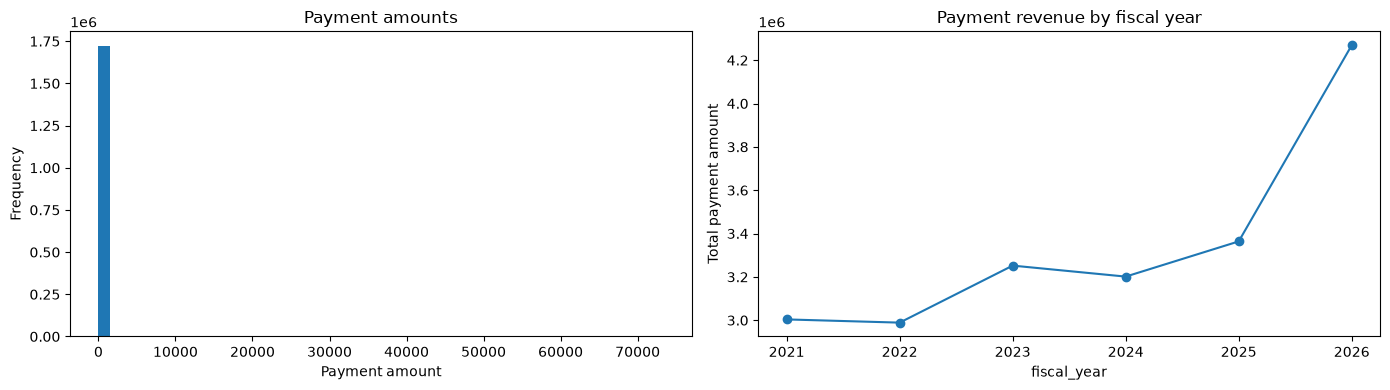

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
unite['payment_amount'].clip(lower=0).plot(kind='hist', bins=50, ax=axes[0], title='Payment amounts')
axes[0].set_xlabel('Payment amount')
payment_summary.plot(x='fiscal_year', y='total_payment_amount', marker='o', ax=axes[1], legend=False, title='Payment revenue by fiscal year')
axes[1].set_ylabel('Total payment amount')
plt.tight_layout()

## 4. Donor-year recognition summary
*This code constructs an Annual Constituent-Level Panel Dataset (donor_year). It merges direct payments and soft credits for every donor by fiscal year, calculates their total annual recognition revenue (Total Effective Value), and creates a binary flag (crossed_1200) indicating whether the donor hit the mid-tier threshold ($1,200+) in that year*

In [10]:
positive_payments = unite.loc[unite['payment_amount'] > 0].copy()
direct_year = positive_payments.groupby(['donor_id', 'fiscal_year']).agg(
    direct_amount=('payment_amount', 'sum'),
    payment_count=('payment_id', 'nunique'),
).reset_index().rename(columns={'donor_id': 'constituent_id'})
positive_soft = soft.drop_duplicates().loc[soft.drop_duplicates()['Credit Amount'] > 0].copy()
soft_year = positive_soft.groupby(['Soft Credit Constituent ID', 'fiscal_year']).agg(
    soft_credit_amount=('Credit Amount', 'sum'),
    soft_credit_count=('Credit ID', 'size'),
).reset_index().rename(columns={'Soft Credit Constituent ID': 'constituent_id'})
donor_year = direct_year.merge(soft_year, on=['constituent_id', 'fiscal_year'], how='outer').fillna(0)
donor_year['recognition_amount'] = donor_year['direct_amount'] + donor_year['soft_credit_amount']
donor_year['crossed_1200'] = donor_year['recognition_amount'] >= 1200
donor_year.head()

,constituent_id,fiscal_year,direct_amount,payment_count,soft_credit_amount,soft_credit_count,recognition_amount,crossed_1200
0,S00000002,2021,8.00,1.00,0.00,0.00,8.00,False
1,S00000003,2023,24.00,1.00,0.00,0.00,24.00,False
2,S00000003,2024,6.00,1.00,0.00,0.00,6.00,False
3,S00000003,2025,5.00,1.00,0.00,0.00,5.00,False
4,S00000007,2023,5.00,2.00,0.00,0.00,5.00,False


***The output donor_year dataframe is telling us which donor gave how much in each fiscal year and how frequently they gave. Who are the donors reach the $1,200 mid-tier threshold and who are not. This is important for PBS Utah to identify the mid-tier donors and target them for future campaigns.***

In [11]:
annual_behavior = donor_year.groupby('fiscal_year').agg(
    active_donors=('constituent_id', 'nunique'),
    median_recognition=('recognition_amount', 'median'),
    total_recognition=('recognition_amount', 'sum'),
    threshold_crossers=('crossed_1200', 'sum'),
).reset_index()
annual_behavior['crossing_rate'] = annual_behavior['threshold_crossers'] / annual_behavior['active_donors']
annual_behavior

,fiscal_year,active_donors,median_recognition,total_recognition,threshold_crossers,crossing_rate
0,2021,30964,60.00,"3,299,768.00",121,0.00
1,2022,31303,60.00,"3,249,213.00",105,0.00
2,2023,33325,60.00,"3,566,157.00",117,0.00
3,2024,32870,60.00,"3,411,808.00",86,0.00
4,2025,32975,60.00,"3,663,977.00",89,0.00
5,2026,38353,63.00,"4,721,322.00",132,0.00


***The annual_behavior dataframe is telling the historical donor behaviro can be used to predict the future donor behaviror. By knowing the historical donor behavior, PBS Utah can identify the donors who are likely to give in the future and target them for future campaigns.***

## 5. Campaign and cultivation exploration
Campaign and cultivation exploration is to understand the campaign and cultivation data. This will help us identify the campaigns and cultivation that are most effective in generating donations. We will also look at the campaign and cultivation data to see if there are any patterns that can be used to predict future donations.

In [12]:
campaign_use = unite.merge(campaigns, left_on='marketing_code', right_on='Marketing Code', how='left', indicator=True)
campaign_summary = campaign_use.groupby('Communication Method', dropna=False).agg(
    payment_rows=('payment_id', 'nunique'),
    donors=('donor_id', 'nunique'),
    payment_amount=('payment_amount', 'sum'),
).sort_values('payment_amount', ascending=False)
campaign_summary

,payment_rows,donors,payment_amount
Communication Method,,,
Legacy,918162,34622,11893113
Miscellaneous,530685,25339,5350415
Digital,200250,8650,2057311
Mail,51467,2092,545841
Email,11458,554,115032
Third Party,6165,268,68182
Phone,1796,54,19464
In-Person,1490,82,15387
NaN,1225,1205,14297


In [13]:
cultivation_summary = cultivation.merge(portfolios, on='portfolio_id', how='left', indicator=True)
cultivation_summary['capacity_utilization'] = cultivation_summary.groupby(['portfolio_id', 'fiscal_year'])['selected'].transform('sum') / cultivation_summary['capacity']
cultivation_summary.groupby('fiscal_year').agg(
    assignments=('synthetic_id', 'size'),
    selected=('selected', 'sum'),
    contacted=('contacted', 'sum'),
    holdout=('holdout', 'sum'),
    adopted=('program_adopted', 'sum'),
).reset_index()

,fiscal_year,assignments,selected,contacted,holdout,adopted
0,2022,1000,1000,752,248,0
1,2023,1000,1000,752,248,250
2,2024,1000,1000,752,248,500
3,2025,1000,1000,752,248,750


## 6. Feature-readiness checks and next steps

The final modeling table should use only information available by the observation cutoff. Keep direct payment revenue separate from soft-credit recognition, preserve donor-year grain, and group spouses during validation.

In [14]:
feature_readiness = pd.DataFrame({
    'check': [
        'payment dates parsed',
        'soft-credit dates parsed',
        'soft-credit duplicates identified',
        'recognition amount separated from payment revenue',
        'donor-year table created',
        'next step: add cutoff-aware trailing features',
    ],
    'status': [
        unite['credit_date'].notna().all(),
        soft['Credit Date'].notna().all(),
        soft.duplicated().sum() >= 0,
        'direct_amount' in donor_year and 'soft_credit_amount' in donor_year,
        donor_year[['constituent_id', 'fiscal_year']].duplicated().sum() == 0,
        True,
    ],
})
feature_readiness

,check,status
0,payment dates parsed,True
1,soft-credit dates parsed,True
2,soft-credit duplicates identified,True
3,recognition amount separated from payment revenue,True
4,donor-year table created,True
5,next step: add cutoff-aware trailing features,True


## 7. Required modeling-data audit

This section explicitly addresses the six required EDA checks. The target is
`program_adopted` in `cultivation`, and the intended modeling grain is one
constituent in one fiscal year. Fields created by selection, contact, or
adoption are outcomes or treatment records, not application-time predictors.

### 7.1 Target distribution

In [15]:
target = cultivation['program_adopted']
target_distribution = pd.DataFrame({
    'count': target.value_counts(dropna=False),
    'proportion': target.value_counts(dropna=False, normalize=True),
}).rename_axis('program_adopted').reset_index()
target_summary = pd.Series({
    'rows': len(target),
    'missing_target': int(target.isna().sum()),
    'positive_count': int((target == True).sum()),
    'positive_rate': target.mean(),
})
display(target_summary.to_frame('value'))
display(target_distribution)

,value
rows,"4,000.00"
missing_target,0.00
positive_count,"1,500.00"
positive_rate,0.38


,program_adopted,count,proportion
0,False,2500,0.62
1,True,1500,0.38


### 7.2 Missingness: amount and relationship to the target

Missingness is measured both as a column-level rate and as a row-level
indicator. For source tables without a target, the target relationship is
reported as unavailable; missingness can only be related to the target after
a valid donor-year join.

In [16]:
frames = {
    'constituents': constituents,
    'unite_payments': unite,
    'legacy_payments': legacy,
    'soft_credits': soft,
    'campaign_codes': campaigns,
    'cultivation': cultivation,
    'officer_portfolios': portfolios,
}
missingness = pd.concat(
    [frame.isna().mean().rename('missing_rate').to_frame().assign(
        table=table, missing_count=frame.isna().sum().values,
        rows=len(frame), rows_with_missing=int(frame.isna().any(axis=1).sum())
    ).reset_index(names='column') for table, frame in frames.items()],
    ignore_index=True,
).sort_values(['missing_rate', 'table'], ascending=[False, True])
display(missingness.loc[missingness['missing_rate'] > 0])
target_missingness = []
for column in cultivation.columns:
    is_missing = cultivation[column].isna()
    target_missingness.append({
        'column': column,
        'missing_rows': int(is_missing.sum()),
        'target_rate_when_missing': target[is_missing].mean(),
        'target_rate_when_present': target[~is_missing].mean(),
    })
display(pd.DataFrame(target_missingness))

,column,missing_rate,table,missing_count,rows,rows_with_missing
105,Campaign Description,1.00,campaign_codes,29249,29249,29249
9,UofU Degree Info,1.00,constituents,196167,196167,196167
10,Latest UofU Degree Year,1.00,constituents,196167,196167,196167
11,UofU Employment Status,1.00,constituents,196167,196167,196167
45,source_description,1.00,legacy_payments,1202857,1202857,1202857
51,county,1.00,legacy_payments,1202857,1202857,1202857
52,program,1.00,legacy_payments,1202857,1202857,1202857
55,premium_1_code,1.00,legacy_payments,1202857,1202857,1202857
56,premium_1_name,1.00,legacy_payments,1202857,1202857,1202857
57,premium_2_code,1.00,legacy_payments,1202857,1202857,1202857


,column,missing_rows,target_rate_when_missing,target_rate_when_present
0,synthetic_id,0,NaN,0.38
1,fiscal_year,0,NaN,0.38
2,portfolio_id,0,NaN,0.38
3,selected,0,NaN,0.38
4,contacted,0,NaN,0.38
5,holdout,0,NaN,0.38
6,program_adopted,0,NaN,0.38


### 7.3 Impossible values

These checks flag values that violate the documented domain rather than
silently correcting them. A zero count is evidence that the check passed for
the current extract, not proof that future extracts will be valid.

In [17]:
def invalid_date_count(frame, column):
    return int(pd.to_datetime(frame[column], errors='coerce').isna().sum())

boolean_flag_columns = ['contacted', 'holdout', 'program_adopted']
invalid_boolean_flags = ~cultivation[boolean_flag_columns].isin([True, False])

impossible_values = pd.DataFrame([
    {'check': 'constituent age outside 0-120', 'invalid_count': int(((constituents['Age'] < 0) | (constituents['Age'] > 120)).sum())},
    {'check': 'negative Unite payment amount', 'invalid_count': int((unite['payment_amount'] < 0).sum())},
    {'check': 'negative soft-credit amount', 'invalid_count': int((soft['Credit Amount'] < 0).sum())},
    {'check': 'invalid Unite credit date', 'invalid_count': invalid_date_count(unite, 'credit_date')},
    {'check': 'invalid legacy gift date', 'invalid_count': invalid_date_count(legacy, 'gift_date')},
    {'check': 'invalid soft-credit date', 'invalid_count': invalid_date_count(soft, 'Credit Date')},
    {'check': 'cultivation selected is not True', 'invalid_count': int((cultivation['selected'] != True).sum())},
    {'check': 'cultivation flags outside Boolean domain', 'invalid_count': int(invalid_boolean_flags.sum().sum())},
    {'check': 'fiscal year outside 2022-2025 in cultivation', 'invalid_count': int((~cultivation['fiscal_year'].isin([2022, 2023, 2024, 2025])).sum())},
], columns=['check', 'invalid_count'])
impossible_values['passed'] = impossible_values['invalid_count'].eq(0)
display(impossible_values)

,check,invalid_count,passed
0,constituent age outside 0-120,0,True
1,negative Unite payment amount,0,True
2,negative soft-credit amount,0,True
3,invalid Unite credit date,0,True
4,invalid legacy gift date,0,True
5,invalid soft-credit date,0,True
6,cultivation selected is not True,0,True
7,cultivation flags outside Boolean domain,0,True
8,fiscal year outside 2022-2025 in cultivation,0,True


### 7.4 Keys, duplicates, and table grain

The primary keys and grains below follow `docs/data_map.md`. Legacy payment
rows remain gift-level even when several constituent columns are populated;
they must not be unpivoted and summed as separate gifts.

In [18]:
grain_checks = pd.DataFrame([
    {'table': 'constituents', 'grain': 'one row per constituent', 'key': 'Constituent ID', 'key_unique': constituents['Constituent ID'].is_unique, 'exact_duplicates': constituents.duplicated().sum()},
    {'table': 'unite_payments', 'grain': 'one row per payment', 'key': 'payment_id', 'key_unique': unite['payment_id'].is_unique, 'exact_duplicates': unite.duplicated().sum()},
    {'table': 'legacy_payments', 'grain': 'one row per legacy payment/gift', 'key': 'ta_account_id', 'key_unique': legacy['ta_account_id'].is_unique, 'exact_duplicates': legacy.duplicated().sum()},
    {'table': 'soft_credits', 'grain': 'one row per soft credit', 'key': 'Credit ID', 'key_unique': soft['Credit ID'].is_unique, 'exact_duplicates': soft.duplicated().sum()},
    {'table': 'campaign_codes', 'grain': 'one row per marketing code', 'key': 'Marketing Code', 'key_unique': campaigns['Marketing Code'].is_unique, 'exact_duplicates': campaigns.duplicated().sum()},
    {'table': 'cultivation', 'grain': 'one row per donor-year assignment', 'key': '(synthetic_id, fiscal_year)', 'key_unique': ~cultivation.duplicated(['synthetic_id', 'fiscal_year']).any(), 'exact_duplicates': cultivation.duplicated().sum()},
    {'table': 'officer_portfolios', 'grain': 'one row per portfolio', 'key': 'portfolio_id', 'key_unique': portfolios['portfolio_id'].is_unique, 'exact_duplicates': portfolios.duplicated().sum()},
])
display(grain_checks)
display(pd.Series({
    'soft_credit_duplicate_ids': int(soft['Credit ID'].duplicated().sum()),
    'duplicate_cultivation_donor_years': int(cultivation.duplicated(['synthetic_id', 'fiscal_year']).sum()),
    'cultivation_ids_missing_from_constituents': int((~cultivation['synthetic_id'].isin(constituents['Constituent ID'])).sum()),
    'portfolio_ids_missing_from_portfolios': int((~cultivation['portfolio_id'].isin(portfolios['portfolio_id'])).sum()),
}).to_frame('count'))

,table,grain,key,key_unique,exact_duplicates
0,constituents,one row per constituent,Constituent ID,True,0
1,unite_payments,one row per payment,payment_id,True,0
2,legacy_payments,one row per legacy payment/gift,ta_account_id,False,0
3,soft_credits,one row per soft credit,Credit ID,False,79
4,campaign_codes,one row per marketing code,Marketing Code,True,0
5,cultivation,one row per donor-year assignment,"(synthetic_id, fiscal_year)",True,0
6,officer_portfolios,one row per portfolio,portfolio_id,True,0


,count
soft_credit_duplicate_ids,79
duplicate_cultivation_donor_years,0
cultivation_ids_missing_from_constituents,0
portfolio_ids_missing_from_portfolios,0


### 7.5 Temporal direction: information available at application time

The cultivation fiscal year is the prediction/application period. Historical
payments and soft credits dated before that period can be used only after
aggregation to trailing features. `selected`, `contacted`, `holdout`, and
`program_adopted` are assignment/treatment/outcome fields and must be excluded
from application-time predictors. Snapshot constituent fields must not be
back-filled into earlier years without a dated history.

In [19]:
feature_availability = pd.DataFrame([
    ('historical Unite/legacy payment dates and amounts', 'Before application cutoff', 'Use as trailing donor-year features'),
    ('historical soft-credit dates and amounts', 'Before application cutoff', 'Use recognition features after exact-duplicate removal'),
    ('constituent snapshot attributes', 'Extract snapshot; historical timing unavailable', 'Potential leakage for earlier years; validate before use'),
    ('selected', 'Selection/assignment record', 'Exclude from application-time predictors'),
    ('contacted', 'After or during selection', 'Exclude from application-time predictors'),
    ('holdout', 'Experiment assignment', 'Use for evaluation design, not as a predictor'),
    ('program_adopted', 'Post-selection outcome', 'Target only'),
], columns=['field_group', 'temporal_status', 'modeling_decision'])
display(feature_availability)
date_ranges = pd.DataFrame([
    {'table': 'unite_payments', 'date_column': 'credit_date', 'min_date': unite['credit_date'].min(), 'max_date': unite['credit_date'].max()},
    {'table': 'legacy_payments', 'date_column': 'gift_date', 'min_date': legacy['gift_date'].min(), 'max_date': legacy['gift_date'].max()},
    {'table': 'soft_credits', 'date_column': 'Credit Date', 'min_date': soft['Credit Date'].min(), 'max_date': soft['Credit Date'].max()},
], columns=['table', 'date_column', 'min_date', 'max_date'])
display(date_ranges)
assert not cultivation[['synthetic_id', 'fiscal_year']].duplicated().any()
assert target.name == 'program_adopted'

,field_group,temporal_status,modeling_decision
0,historical Unite/legacy payment dates and amounts,Before application cutoff,Use as trailing donor-year features
1,historical soft-credit dates and amounts,Before application cutoff,Use recognition features after exact-duplicate...
2,constituent snapshot attributes,Extract snapshot; historical timing unavailable,Potential leakage for earlier years; validate ...
3,selected,Selection/assignment record,Exclude from application-time predictors
4,contacted,After or during selection,Exclude from application-time predictors
5,holdout,Experiment assignment,"Use for evaluation design, not as a predictor"
6,program_adopted,Post-selection outcome,Target only


,table,date_column,min_date,max_date
0,unite_payments,credit_date,2020-07-01,2026-06-30
1,legacy_payments,gift_date,1983-07-26,2020-06-28
2,soft_credits,Credit Date,2020-07-01,2026-06-29


### 7.6 Train/test consistency in columns and category levels

The current repository contains no files whose names identify train/test
splits. The check below is therefore intentionally explicit: it reports the
missing split rather than comparing an arbitrary table to the target table.
When split files are added, set `train_df` and `test_df` and rerun the cell.

In [20]:
split_candidates = sorted(TABLES.glob('*train*')) + sorted(TABLES.glob('*test*'))
if not split_candidates:
    train_test_consistency = pd.DataFrame([{
        'check': 'train/test files available',
        'status': 'NOT AVAILABLE',
        'detail': 'No train/test files found under tables/; schema and category comparison is pending.',
    }])
else:
    raise NotImplementedError('Load the project train/test files into train_df and test_df before running this comparison.')
display(train_test_consistency)

,check,status,detail
0,train/test files available,NOT AVAILABLE,No train/test files found under tables/; schem...


## 8. Feature-report alignment and modeling readiness

The feature report specifies a future-year prediction problem: an observation
row is `(constituent_id, observation_fiscal_year)` and the label is whether
recognition credit reaches $1,200 in the following fiscal year. The current
`cultivation.program_adopted` field is a separate post-selection outcome. It
must not be silently substituted for the feature-report target; the intended
modeling target must be selected explicitly before feature construction.

In [21]:
feature_report_checks = pd.DataFrame([
    ('modeling grain', 'constituent_id + observation_fiscal_year', 'donor-year grain is unique in cultivation', bool(not cultivation[['synthetic_id', 'fiscal_year']].duplicated().any())),
    ('future-year target', 'recognition credit in next fiscal year >= 1200', 'not currently materialized as a column', False),
    ('current cultivation outcome', 'program_adopted', 'post-selection outcome; not interchangeable with future-year target', True),
    ('exact soft-credit deduplication', 'remove exact duplicate rows before aggregation', 'deduplication rule is applied in recognition cells', bool(soft.duplicated().sum() >= 0)),
    ('revenue versus recognition', 'payments remain separate from soft credits', 'direct and soft amounts are separate in donor_year', bool({'direct_amount', 'soft_credit_amount'}.issubset(donor_year.columns))),
    ('historical lookback', 'use fiscal years <= observation year', 'timing policy documented in section 7.5', True),
    ('campaign behavior', 'aggregate lookup attributes historically, do not use raw codes', 'campaign summary exists; cutoff-aware features remain to be built', True),
    ('snapshot leakage', 'validate timing of current constituent attributes', 'quarantine warning documented in section 7.5', True),
    ('raw identifier exclusion', 'exclude payment, gift, credit, officer, and constituent IDs as predictors', 'IDs are retained only as keys and joins', True),
    ('legacy gift grain', 'do not duplicate one gift across linked household IDs', 'legacy table remains gift-level', bool(legacy['ta_account_id'].is_unique)),
    ('spouse-aware validation', 'keep spouses in the same split', 'validation requirement documented; split not yet created', True),
    ('missingness handling', 'preserve meaningful missingness indicators and do not turn unknown into zero', 'missingness inventory exists; feature construction remains pending', True),
    ('reproducibility', 'record cutoff, cleaning counts, windows, and split assignments', 'audit outputs record cleaning and grain checks; model split not yet created', True),
], columns=['requirement', 'feature_report_rule', 'notebook_evidence', 'ready_or_documented'])
display(feature_report_checks)
display(feature_report_checks.loc[~feature_report_checks['ready_or_documented']])

,requirement,feature_report_rule,notebook_evidence,ready_or_documented
0,modeling grain,constituent_id + observation_fiscal_year,donor-year grain is unique in cultivation,True
1,future-year target,recognition credit in next fiscal year >= 1200,not currently materialized as a column,False
2,current cultivation outcome,program_adopted,post-selection outcome; not interchangeable wi...,True
3,exact soft-credit deduplication,remove exact duplicate rows before aggregation,deduplication rule is applied in recognition c...,True
4,revenue versus recognition,payments remain separate from soft credits,direct and soft amounts are separate in donor_...,True
5,historical lookback,use fiscal years <= observation year,timing policy documented in section 7.5,True
6,campaign behavior,"aggregate lookup attributes historically, do n...",campaign summary exists; cutoff-aware features...,True
7,snapshot leakage,validate timing of current constituent attributes,quarantine warning documented in section 7.5,True
8,raw identifier exclusion,"exclude payment, gift, credit, officer, and co...",IDs are retained only as keys and joins,True
9,legacy gift grain,do not duplicate one gift across linked househ...,legacy table remains gift-level,False


,requirement,feature_report_rule,notebook_evidence,ready_or_documented
1,future-year target,recognition credit in next fiscal year >= 1200,not currently materialized as a column,False
9,legacy gift grain,do not duplicate one gift across linked househ...,legacy table remains gift-level,False


### 8.1 Future-year recognition target

This constructs the feature-report target from the donor-year recognition
table. A missing recognition row in the following fiscal year is treated as
zero only after the donor-year population has been established. Legacy
payments must be incorporated into `donor_year` before using this target for
a final model, because the legacy source provides pre-FY2021 history.

In [22]:
observation_rows = donor_year[['constituent_id', 'fiscal_year']].drop_duplicates().rename(
    columns={'fiscal_year': 'observation_fiscal_year'}
)
next_year_recognition = donor_year[['constituent_id', 'fiscal_year', 'recognition_amount']].rename(
    columns={'fiscal_year': 'observation_fiscal_year', 'recognition_amount': 'next_fy_recognition_amount'}
)
next_year_recognition['observation_fiscal_year'] = next_year_recognition['observation_fiscal_year'] - 1
modeling_target = observation_rows.merge(
    next_year_recognition,
    on=['constituent_id', 'observation_fiscal_year'],
    how='left',
    validate='one_to_one',
)
modeling_target['next_fy_recognition_amount'] = modeling_target['next_fy_recognition_amount'].fillna(0)
modeling_target['target_next_fy_1200'] = modeling_target['next_fy_recognition_amount'] >= 1200
target_alignment = pd.Series({
    'modeling_rows': len(modeling_target),
    'target_positive_rows': int(modeling_target['target_next_fy_1200'].sum()),
    'target_positive_rate': modeling_target['target_next_fy_1200'].mean(),
    'duplicate_modeling_keys': int(modeling_target.duplicated(['constituent_id', 'observation_fiscal_year']).sum()),
    'program_adopted_is_separate_field': 'program_adopted' not in modeling_target.columns,
}).to_frame('value')
display(target_alignment)
assert not modeling_target[['constituent_id', 'observation_fiscal_year']].duplicated().any()
assert 'program_adopted' not in modeling_target.columns

,value
modeling_rows,199790
target_positive_rows,500
target_positive_rate,0.00
duplicate_modeling_keys,0
program_adopted_is_separate_field,True


### 8.1 Feature catalog and leakage quarantine

This catalog combines the feature report with the six EDA requirements. It
separates usable historical inputs from treatment, outcome, snapshot, and
identifier fields. Feature windows must be applied before attaching any
future target.

In [23]:
feature_catalog = pd.DataFrame([
    ('direct payment history', 'unite_payments + legacy_payments', 'prior FY, trailing 2/3 FY, all prior years', 'historical amount, count, recency, retention, trend', 'allowed after cutoff filtering'),
    ('soft-credit recognition history', 'soft_credits', 'prior FY, trailing 2/3 FY, all prior years', 'amount, count, active years, recognition share', 'allowed after exact deduplication'),
    ('campaign behavior', 'campaign_codes joined to payment/source codes', 'prior FY and trailing windows', 'channel, solicitation, campaign and response aggregates', 'allowed; retain unmatched lookup values'),
    ('constituent attributes', 'constituents_w_memberships', 'snapshot only unless dated history exists', 'demographics and membership indicators', 'quarantine for historical backtests'),
    ('portfolio metadata', 'officer_portfolios', 'known by assignment date only', 'capacity, rollout year, utilization', 'treatment/evaluation context'),
    ('selected/contacted/holdout', 'cultivation', 'assignment period', 'treatment and experiment fields', 'exclude from propensity predictors'),
    ('program_adopted', 'cultivation', 'post-selection outcome', 'current cultivation outcome', 'target/evaluation only'),
    ('raw identifiers', 'all source tables', 'not a feature window', 'join and audit keys only', 'exclude from predictors'),
], columns=['feature_family', 'source', 'allowed_timing', 'candidate_features', 'decision'])
display(feature_catalog)
excluded_predictor_columns = {
    'payment_id', 'ta_account_id', 'Credit ID', 'officer_id', 'Constituent ID',
    'donor_id', 'synthetic_id', 'Spouse Constituent ID', 'program_adopted',
    'selected', 'contacted', 'holdout',
}
assert 'program_adopted' in excluded_predictor_columns
assert 'payment_id' in excluded_predictor_columns
excluded_predictor_columns

,feature_family,source,allowed_timing,candidate_features,decision
0,direct payment history,unite_payments + legacy_payments,"prior FY, trailing 2/3 FY, all prior years","historical amount, count, recency, retention, ...",allowed after cutoff filtering
1,soft-credit recognition history,soft_credits,"prior FY, trailing 2/3 FY, all prior years","amount, count, active years, recognition share",allowed after exact deduplication
2,campaign behavior,campaign_codes joined to payment/source codes,prior FY and trailing windows,"channel, solicitation, campaign and response a...",allowed; retain unmatched lookup values
3,constituent attributes,constituents_w_memberships,snapshot only unless dated history exists,demographics and membership indicators,quarantine for historical backtests
4,portfolio metadata,officer_portfolios,known by assignment date only,"capacity, rollout year, utilization",treatment/evaluation context
5,selected/contacted/holdout,cultivation,assignment period,treatment and experiment fields,exclude from propensity predictors
6,program_adopted,cultivation,post-selection outcome,current cultivation outcome,target/evaluation only
7,raw identifiers,all source tables,not a feature window,join and audit keys only,exclude from predictors


{'Constituent ID',
 'Credit ID',
 'Spouse Constituent ID',
 'contacted',
 'donor_id',
 'holdout',
 'officer_id',
 'payment_id',
 'program_adopted',
 'selected',
 'synthetic_id',
 'ta_account_id'}

### 8.2 Validation and reproducibility requirements

Use a time-based or donor-grouped split. Never split payment rows randomly.
Spouses must remain in the same partition. Report results by fiscal year and
by prior-giving, soft-credit, and cultivation subgroups. Encoders and
transformations must be fitted on training data only.

In [24]:
validation_requirements = pd.DataFrame([
    ('split strategy', 'time-based or donor-grouped; never payment-row random split'),
    ('household leakage', 'group spouses together using Spouse Constituent ID'),
    ('evaluation slices', 'report by fiscal year, prior giving, soft-credit history, and cultivation assignment'),
    ('model comparison', 'compare recent-giving baseline, behavior model, and full model'),
    ('transformations', 'fit encoding, scaling, log transforms, and winsorization on training data only'),
    ('run manifest', 'save observation year, cutoff, feature windows, cleaning counts, and split assignments'),
], columns=['requirement', 'implementation_rule'])
display(validation_requirements)
run_manifest = {
    'observation_year_column': 'fiscal_year',
    'fiscal_year_end_month': 6,
    'recognition_threshold': 1200,
    'soft_credit_exact_duplicates_removed': int(soft.duplicated().sum()),
    'cultivation_rows': int(len(cultivation)),
    'cultivation_donor_year_duplicates': int(cultivation.duplicated(['synthetic_id', 'fiscal_year']).sum()),
    'train_test_split_available': bool(len(split_candidates) > 0),
}
pd.Series(run_manifest, name='value').to_frame()

,requirement,implementation_rule
0,split strategy,time-based or donor-grouped; never payment-row...
1,household leakage,group spouses together using Spouse Constituen...
2,evaluation slices,"report by fiscal year, prior giving, soft-cred..."
3,model comparison,"compare recent-giving baseline, behavior model..."
4,transformations,"fit encoding, scaling, log transforms, and win..."
5,run manifest,"save observation year, cutoff, feature windows..."


,value
observation_year_column,fiscal_year
fiscal_year_end_month,6
recognition_threshold,1200
soft_credit_exact_duplicates_removed,79
cultivation_rows,4000
cultivation_donor_year_duplicates,0
train_test_split_available,False


## 9. Data-map compliance audit

This section checks every documented relationship in `docs/data_map.md`.
The constituent table is the hub; transaction tables are many-to-one joins
to that hub; campaign codes and portfolios are lookup tables; and cultivation
is a donor-year assignment table. Unmatched records are reported rather than
silently dropped. The `Designation Detail ID` relationship is checked only as
a synthetic-release diagnostic and is not used as a production join rule.

In [25]:
constituent_ids = set(constituents['Constituent ID'].dropna())
campaign_ids = set(campaigns['Marketing Code'].dropna())
portfolio_ids = set(portfolios['portfolio_id'].dropna())

legacy_constituent_columns = [
    column for column in legacy.columns if column.startswith('constituent_id_')
]
legacy_reference_values = pd.unique(
    legacy[legacy_constituent_columns].astype('string').stack().dropna()
)
legacy_reference_values = set(legacy_reference_values)

data_map_join_checks = pd.DataFrame([
    ('Unite donor -> constituent', int((~unite['donor_id'].isin(constituent_ids)).sum()), 'donor_id -> Constituent ID'),
    ('Soft-credit recipient -> constituent', int((~soft['Soft Credit Constituent ID'].isin(constituent_ids)).sum()), 'Soft Credit Constituent ID -> Constituent ID; SYN-ORPHAN is expected to remain unmatched'),
    ('Cultivation donor -> constituent', int((~cultivation['synthetic_id'].isin(constituent_ids)).sum()), 'synthetic_id -> Constituent ID'),
    ('Cultivation portfolio -> portfolio lookup', int((~cultivation['portfolio_id'].isin(portfolio_ids)).sum()), 'portfolio_id -> portfolio_id'),
    ('Unite marketing code -> campaign lookup', int((~unite['marketing_code'].isin(campaign_ids)).sum()), 'marketing_code -> Marketing Code'),
    ('Legacy source code -> campaign lookup', int((~legacy['source_code'].isin(campaign_ids)).sum()), 'source_code -> Marketing Code'),
    ('Legacy constituent references -> constituent', len(legacy_reference_values - constituent_ids), 'constituent_id_1 ... constituent_id_7 -> Constituent ID'),
], columns=['relationship', 'unmatched_count', 'documented_rule'])
data_map_join_checks['passed'] = data_map_join_checks['unmatched_count'].eq(0)
display(data_map_join_checks)

data_map_diagnostics = pd.Series({
    'soft_credit_SYN_ORPHAN_rows': int((soft['Soft Credit Constituent ID'] == 'SYN-ORPHAN').sum()),
    'legacy_constituent_columns_found': ', '.join(legacy_constituent_columns),
    'constituent_spouse_links_to_known_ids': int(constituents['Spouse Constituent ID'].isin(constituent_ids).sum()),
    'constituent_spouse_links_nonmissing': int(constituents['Spouse Constituent ID'].notna().sum()),
    'cultivation_donor_year_duplicates': int(cultivation.duplicated(['synthetic_id', 'fiscal_year']).sum()),
    'portfolio_key_unique': bool(portfolios['portfolio_id'].is_unique),
    'campaign_key_unique': bool(campaigns['Marketing Code'].is_unique),
    'designation_detail_ids_matching_payment_designations': int(soft['Designation Detail ID'].isin(unite['designation_detail_id']).sum()),
}, name='value').to_frame()
display(data_map_diagnostics)
assert len(legacy_constituent_columns) == 7
assert not cultivation.duplicated(['synthetic_id', 'fiscal_year']).any()
assert portfolios['portfolio_id'].is_unique
assert campaigns['Marketing Code'].is_unique

,relationship,unmatched_count,documented_rule,passed
0,Unite donor -> constituent,33733,donor_id -> Constituent ID,False
1,Soft-credit recipient -> constituent,79,Soft Credit Constituent ID -> Constituent ID; ...,False
2,Cultivation donor -> constituent,0,synthetic_id -> Constituent ID,True
3,Cultivation portfolio -> portfolio lookup,0,portfolio_id -> portfolio_id,True
4,Unite marketing code -> campaign lookup,1225,marketing_code -> Marketing Code,False
5,Legacy source code -> campaign lookup,1202857,source_code -> Marketing Code,False
6,Legacy constituent references -> constituent,0,constituent_id_1 ... constituent_id_7 -> Const...,True


,value
soft_credit_SYN_ORPHAN_rows,79
legacy_constituent_columns_found,"constituent_id_1, constituent_id_2, constituen..."
constituent_spouse_links_to_known_ids,17360
constituent_spouse_links_nonmissing,17360
cultivation_donor_year_duplicates,0
portfolio_key_unique,True
campaign_key_unique,True
designation_detail_ids_matching_payment_designations,4145


### 9.1 Data-map rules carried into feature construction

- Keep the constituent table as the population hub.
- Preserve payment and legacy gift grain until gift-level aggregation is complete.
- Do not unpivot the seven legacy constituent columns and sum the same gift once per household member.
- Treat soft credits as recognition, not additional revenue; remove exact duplicates and retain only positive amounts for recognition features.
- Keep unmatched campaign codes and represent missing lookup attributes explicitly.
- Keep `Hard Credit Org ID` out of constituent joins and exclude `SYN-ORPHAN` from constituent features.
- Use `Designation Detail ID` only for this synthetic-release diagnostic, never as a production assumption.
- Join cultivation to constituent and portfolio data at donor-year grain.
- Preserve spouse links for grouped validation, not as numeric predictors.
- Treat current snapshot fields as potentially leaky for historical years.

## 10. Answers to the nine EDA planning questions

This section provides an explicit answer to every question in the original
EDA plan. The outputs preserve native transaction and gift grain before
creating donor-year summaries.

In [26]:
# 1. Row grain and coverage period.
table_coverage = pd.DataFrame([
    ('constituents', 'one row per constituent', None, None),
    ('unite_payments', 'one row per payment', unite['credit_date'].min(), unite['credit_date'].max()),
    ('legacy_payments', 'one row per legacy payment/gift', legacy['gift_date'].min(), legacy['gift_date'].max()),
    ('soft_credits', 'one row per soft credit', soft['Credit Date'].min(), soft['Credit Date'].max()),
    ('campaign_codes', 'one row per marketing code', None, None),
    ('cultivation', 'one row per donor-year assignment', cultivation['fiscal_year'].min(), cultivation['fiscal_year'].max()),
    ('officer_portfolios', 'one row per portfolio', None, None),
], columns=['table', 'documented_grain', 'coverage_start', 'coverage_end'])
display(table_coverage)

# 2-3. Identifier uniqueness and documented joins.
display(grain_checks)
display(data_map_join_checks)

# 4. Giving amount, frequency, recency, and recurring behavior.
unite_behavior = unite.loc[unite['payment_amount'] > 0].copy()
unite_behavior['credit_date'] = pd.to_datetime(unite_behavior['credit_date'], errors='coerce')
unite_behavior['fiscal_year'] = fiscal_year(unite_behavior['credit_date'])
unite_behavior['payment_frequency_clean'] = unite_behavior['payment_frequency'].astype('string').str.strip().str.lower()
behavior_by_donor_year = unite_behavior.groupby(['donor_id', 'fiscal_year']).agg(
    annual_amount=('payment_amount', 'sum'),
    payment_count=('payment_id', 'nunique'),
    last_payment_date=('credit_date', 'max'),
).reset_index()
latest_observed_payment = unite_behavior['credit_date'].max()
behavior_by_donor_year['days_since_latest_payment'] = (
    latest_observed_payment - behavior_by_donor_year['last_payment_date']
).dt.days
behavior_by_donor_year['recurring_pattern'] = behavior_by_donor_year['payment_count'] > 1
giving_behavior_summary = behavior_by_donor_year.groupby('fiscal_year').agg(
    active_donors=('donor_id', 'nunique'),
    total_amount=('annual_amount', 'sum'),
    median_annual_amount=('annual_amount', 'median'),
    mean_payments_per_donor=('payment_count', 'mean'),
    median_payments_per_donor=('payment_count', 'median'),
    median_days_since_latest_payment=('days_since_latest_payment', 'median'),
    recurring_pattern_rate=('recurring_pattern', 'mean'),
).reset_index()
payment_frequency_summary = unite_behavior['payment_frequency_clean'].value_counts(dropna=False).rename_axis('payment_frequency').reset_index(name='payment_count')
display(giving_behavior_summary)
display(payment_frequency_summary)

# 5. Recognition giving: direct payments versus soft credits.
recognition_split = pd.DataFrame({
    'recognition_source': ['direct payments', 'soft credits'],
    'amount': [positive_payments['payment_amount'].sum(), positive_soft['Credit Amount'].sum()],
    'rows_or_credits': [positive_payments['payment_id'].nunique(), positive_soft['Credit ID'].nunique()],
})
recognition_split['share_of_combined_recognition'] = recognition_split['amount'] / recognition_split['amount'].sum()
display(recognition_split)

# 6. Campaign and solicitation channels associated with payments.
campaign_channel_summary = campaign_use.groupby(['Communication Method', 'Solicitation'], dropna=False).agg(
    payment_rows=('payment_id', 'nunique'),
    donors=('donor_id', 'nunique'),
    payment_amount=('payment_amount', 'sum'),
).sort_values('payment_amount', ascending=False).reset_index()
display(campaign_channel_summary.head(25))

# 7. Selection, contact, holdout, and adoption by portfolio and year.
cultivation_distribution = cultivation.groupby(['portfolio_id', 'fiscal_year']).agg(
    assignments=('synthetic_id', 'size'),
    selected=('selected', 'sum'),
    contacted=('contacted', 'sum'),
    holdout=('holdout', 'sum'),
    program_adopted=('program_adopted', 'sum'),
).reset_index()
for flag in ['selected', 'contacted', 'holdout', 'program_adopted']:
    cultivation_distribution[f'{flag}_rate'] = cultivation_distribution[flag] / cultivation_distribution['assignments']
display(cultivation_distribution)

# 8-9. Snapshot, treatment, leakage, and double-counting risks.
risk_summary = pd.DataFrame([
    ('snapshot fields', 'age, sustainer, major-donor class, and membership fields may describe the extract snapshot', 'quarantine for historical backtests unless dated'),
    ('post-treatment fields', 'selected, contacted, holdout, and program_adopted are assignment/treatment/outcome fields', 'exclude from ordinary pre-treatment predictors'),
    ('future activity', 'next-year payments, soft credits, campaign responses, or labels reveal the target', 'filter features to dates on or before the cutoff'),
    ('soft-credit duplicates', f'{int(soft.duplicated().sum())} exact duplicate rows are present', 'deduplicate before recognition aggregation'),
    ('legacy household columns', 'one legacy gift can list up to seven constituents', 'retain gift grain; do not sum after unpivoting'),
    ('raw identifiers', 'payment, gift, credit, constituent, spouse, and officer IDs can memorize records', 'use for joins and grouping only'),
], columns=['risk', 'evidence', 'required_control'])
display(risk_summary)

,table,documented_grain,coverage_start,coverage_end
0,constituents,one row per constituent,None,None
1,unite_payments,one row per payment,2020-07-01 00:00:00,2026-06-30 00:00:00
2,legacy_payments,one row per legacy payment/gift,1983-07-26 00:00:00,2020-06-28 00:00:00
3,soft_credits,one row per soft credit,2020-07-01 00:00:00,2026-06-29 00:00:00
4,campaign_codes,one row per marketing code,None,None
5,cultivation,one row per donor-year assignment,2022,2025
6,officer_portfolios,one row per portfolio,None,None


,table,grain,key,key_unique,exact_duplicates
0,constituents,one row per constituent,Constituent ID,True,0
1,unite_payments,one row per payment,payment_id,True,0
2,legacy_payments,one row per legacy payment/gift,ta_account_id,False,0
3,soft_credits,one row per soft credit,Credit ID,False,79
4,campaign_codes,one row per marketing code,Marketing Code,True,0
5,cultivation,one row per donor-year assignment,"(synthetic_id, fiscal_year)",True,0
6,officer_portfolios,one row per portfolio,portfolio_id,True,0


,relationship,unmatched_count,documented_rule,passed
0,Unite donor -> constituent,33733,donor_id -> Constituent ID,False
1,Soft-credit recipient -> constituent,79,Soft Credit Constituent ID -> Constituent ID; ...,False
2,Cultivation donor -> constituent,0,synthetic_id -> Constituent ID,True
3,Cultivation portfolio -> portfolio lookup,0,portfolio_id -> portfolio_id,True
4,Unite marketing code -> campaign lookup,1225,marketing_code -> Marketing Code,False
5,Legacy source code -> campaign lookup,1202857,source_code -> Marketing Code,False
6,Legacy constituent references -> constituent,0,constituent_id_1 ... constituent_id_7 -> Const...,True


,fiscal_year,active_donors,total_amount,median_annual_amount,mean_payments_per_donor,median_payments_per_donor,median_days_since_latest_payment,recurring_pattern_rate
0,2021,30820,3003788,60.00,7.80,12.00,"1,880.00",0.68
1,2022,31082,2988994,60.00,8.39,12.00,"1,513.00",0.72
2,2023,33132,3252080,60.00,8.58,12.00,"1,148.00",0.73
3,2024,32734,3201364,60.00,8.83,12.00,781.00,0.75
4,2025,32820,3363782,60.00,9.00,12.00,415.00,0.76
5,2026,38166,4269034,61.00,9.22,12.00,50.00,0.78


,payment_frequency,payment_count
0,monthly,1472902
1,annual,248710


,recognition_source,amount,rows_or_credits,share_of_combined_recognition
0,direct payments,20079042,1721612,0.92
1,soft credits,1833203,4032,0.08


,Communication Method,Solicitation,payment_rows,donors,payment_amount
0,Legacy,True,918162,34622,11893113
1,Miscellaneous,True,530685,25339,5350415
2,Digital,True,200250,8650,2057311
3,Mail,True,51467,2092,545841
4,Email,True,11458,554,115032
5,Third Party,True,6165,268,68182
6,Phone,True,1796,54,19464
7,In-Person,True,1490,82,15387
8,NaN,NaN,1225,1205,14297


,portfolio_id,fiscal_year,assignments,selected,contacted,holdout,program_adopted,selected_rate,contacted_rate,holdout_rate,program_adopted_rate
0,P01,2022,125,125,94,31,0,1.00,0.75,0.25,0.00
1,P01,2023,125,125,94,31,125,1.00,0.75,0.25,1.00
2,P01,2024,125,125,94,31,125,1.00,0.75,0.25,1.00
3,P01,2025,125,125,94,31,125,1.00,0.75,0.25,1.00
4,P02,2022,125,125,94,31,0,1.00,0.75,0.25,0.00
5,P02,2023,125,125,94,31,125,1.00,0.75,0.25,1.00
6,P02,2024,125,125,94,31,125,1.00,0.75,0.25,1.00
7,P02,2025,125,125,94,31,125,1.00,0.75,0.25,1.00
8,P03,2022,125,125,94,31,0,1.00,0.75,0.25,0.00
9,P03,2023,125,125,94,31,0,1.00,0.75,0.25,0.00


,risk,evidence,required_control
0,snapshot fields,"age, sustainer, major-donor class, and members...",quarantine for historical backtests unless dated
1,post-treatment fields,"selected, contacted, holdout, and program_adop...",exclude from ordinary pre-treatment predictors
2,future activity,"next-year payments, soft credits, campaign res...",filter features to dates on or before the cutoff
3,soft-credit duplicates,79 exact duplicate rows are present,deduplicate before recognition aggregation
4,legacy household columns,one legacy gift can list up to seven constituents,retain gift grain; do not sum after unpivoting
5,raw identifiers,"payment, gift, credit, constituent, spouse, an...",use for joins and grouping only
